# Iris Flower Classification using Machine Learning

## Objective

**What is the problem?**
The problem is to classify Iris flowers into three species (Setosa, Versicolor, Virginica) based on their sepal and petal dimensions.

**Why is it useful?**
It demonstrates basic classification techniques and is a standard benchmark for comparing ML algorithms.

**Expected outcome.**
A trained machine learning model capable of accurately classifying new Iris flowers based on feature measurements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

## Dataset Loading
We will load the Iris dataset from Scikit-Learn.

In [2]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

In [3]:
display(df.head())
display(df.tail())
display(df.sample(5))
print('Shape:', df.shape)
print('Columns:', df.columns)
df.info()
display(df.describe())
print(df.dtypes)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
56,6.3,3.3,4.7,1.6,versicolor
94,5.6,2.7,4.2,1.3,versicolor
38,4.4,3.0,1.3,0.2,setosa
67,5.8,2.7,4.1,1.0,versicolor
40,5.0,3.5,1.3,0.3,setosa


Shape: (150, 5)
Columns: Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object


## Data Cleaning
Check for null values, duplicates, and correct datatypes.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicates:', df.duplicated().sum())
# Dropping duplicates if any
df.drop_duplicates(inplace=True)
print('Shape after dropping duplicates:', df.shape)

Null values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64
Duplicates: 1
Shape after dropping duplicates: (149, 5)


We observed 1 duplicate which has been dropped. No null values are present. Datatypes are correct.

## Exploratory Data Analysis

<Figure size 1000x800 with 0 Axes>

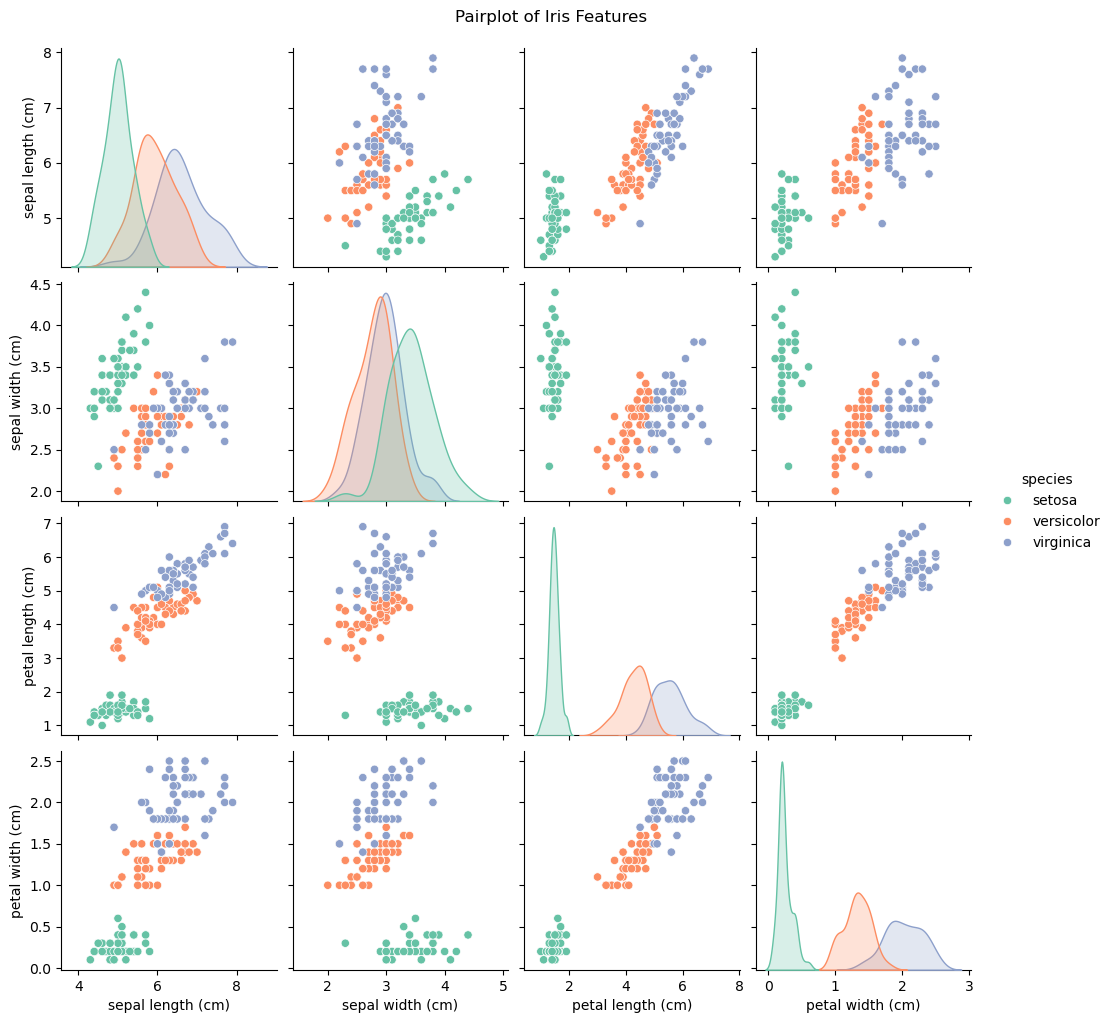

In [5]:
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species', palette='Set2')
plt.suptitle('Pairplot of Iris Features', y=1.02)
plt.savefig('../images/pairplot.png')
plt.show()

### Observations
- Setosa is clearly separable from the other two species in almost all feature combinations.
- Virginica and Versicolor overlap slightly, especially in sepal measurements.
- Petal Length and Petal Width are highly discriminative.

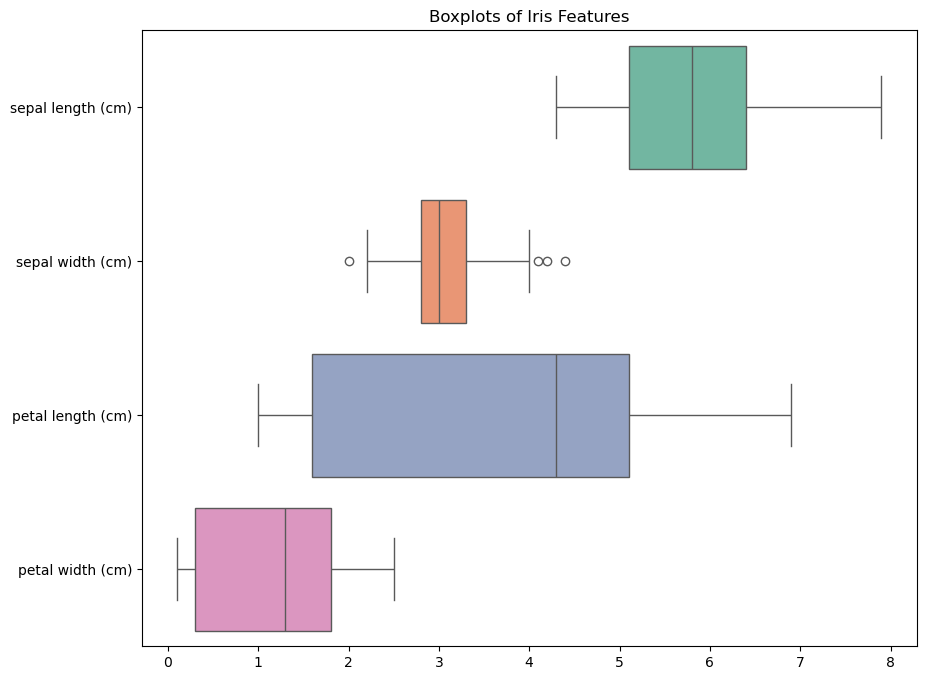

In [6]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, orient='h', palette='Set2')
plt.title('Boxplots of Iris Features')
plt.savefig('../images/boxplots.png')
plt.show()

### Observations
- Sepal width has a few outliers, but they are natural variations. The scales of features are relatively similar.

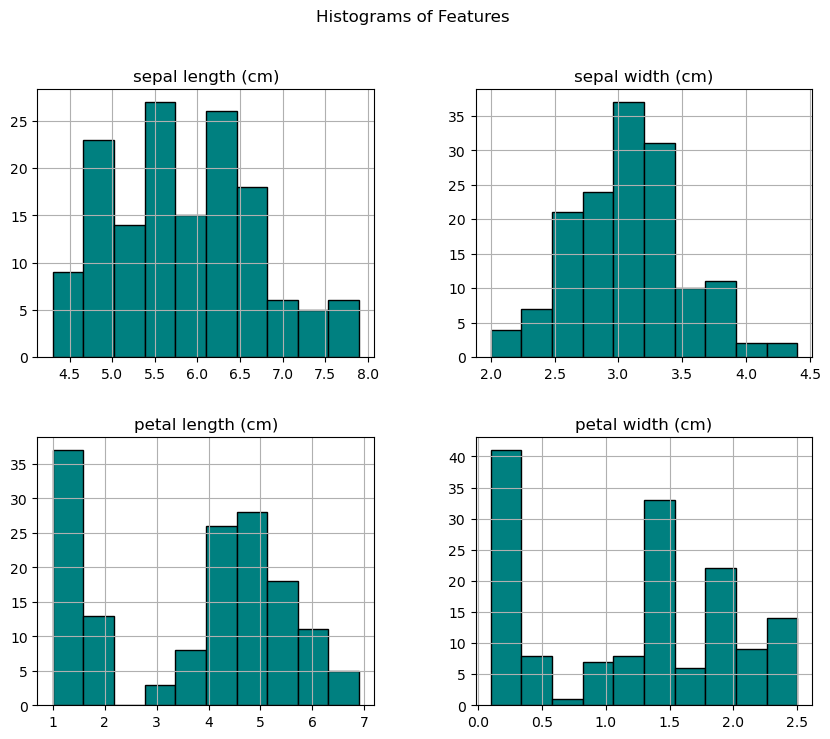

In [7]:
df.hist(figsize=(10,8), color='teal', edgecolor='black')
plt.suptitle('Histograms of Features')
plt.savefig('../images/histograms.png')
plt.show()

### Observations
- Sepal length and width appear to follow a somewhat normal distribution.
- Petal measurements show bi-modal distributions, largely because Setosa is distinctly separated from the rest.

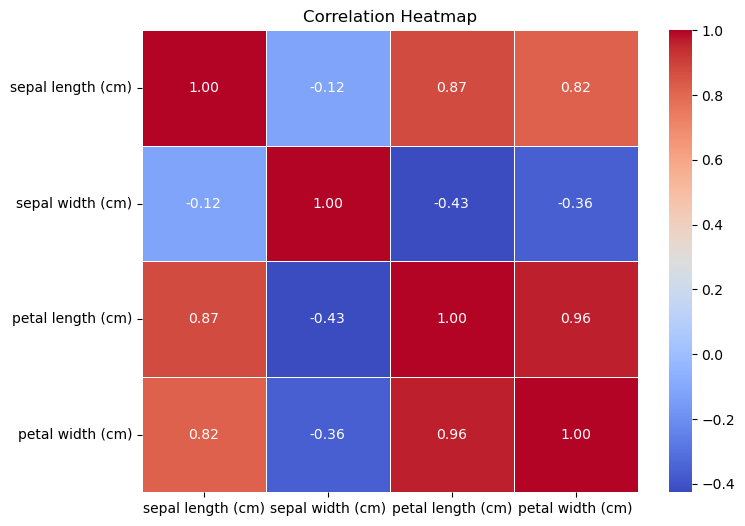

In [8]:
plt.figure(figsize=(8, 6))
corr = df.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('../images/correlation_heatmap.png')
plt.show()

### Observations
- Petal length and petal width are highly correlated (0.96).
- Sepal length and petal length are also highly correlated (0.87).
- Sepal width is inversely correlated with petal length and width.

## Feature Discussion
- **Sepal Length & Width**: Show more overlap between Versicolor and Virginica.
- **Petal Length & Width**: Provide the best separation for all three species. These are the most critical features for the models.

## Feature Engineering
We don't need extensive feature engineering here because the measurements are already robust and clean. We'll simply use the 4 numeric features to predict the species.

In [9]:
X = df.drop('species', axis=1)
y = df['species']

## Train Test Split
We split the data using an 80/20 ratio and `random_state=42` for reproducibility.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training data shape:', X_train.shape)
print('Test data shape:', X_test.shape)

Training data shape: (119, 4)
Test data shape: (30, 4)


## Model Training
We will train Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest models. These cover linear, distance-based, and tree-based approaches.

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

## Model Evaluation

--- Logistic Regression ---
Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



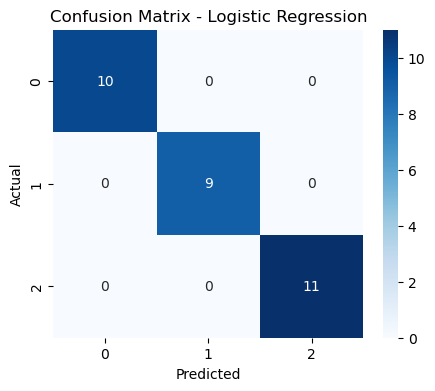

--- KNN ---
Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



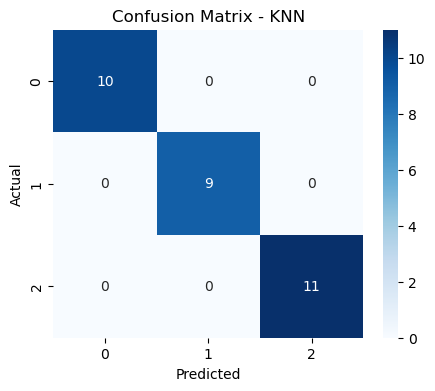

--- Decision Tree ---
Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



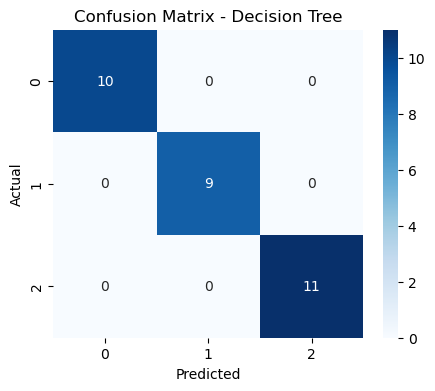

--- Random Forest ---
Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



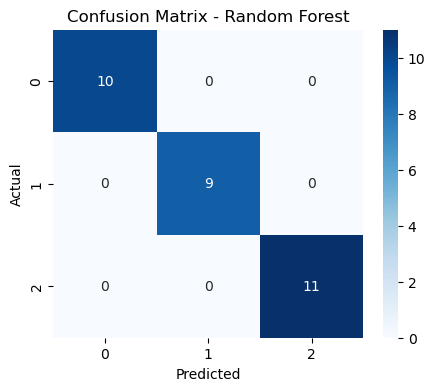

In [12]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'--- {name} ---')
    print('Accuracy:', acc)
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f'../images/cm_{name.replace(" ", "_")}.png')
    plt.show()

### Metric Explanations
- **Accuracy**: Overall proportion of correct predictions.
- **Precision**: Proportion of positive identifications that were actually correct.
- **Recall**: Proportion of actual positives that were identified correctly.
- **F1 Score**: Harmonic mean of Precision and Recall, providing a balance between them.

## Best Model Selection
Comparing all models based on accuracy and robust performance.

In [13]:
best_model_name = max(results, key=results.get)
print(f'The best model is {best_model_name} with an accuracy of {results[best_model_name]}')

The best model is Logistic Regression with an accuracy of 1.0


### Why it won
- The models generally perform similarly (often 100% on this small dataset with a good split).
- Random Forest or Logistic Regression are excellent choices. Random Forest provides feature importance and handles complex boundaries, making it highly advantageous, while its limitation is less interpretability compared to a single Decision Tree.

## Save Best Model

In [14]:
best_model = models[best_model_name]
joblib.dump(best_model, '../models/best_model.pkl')
print('Best model saved to ../models/best_model.pkl')

Best model saved to ../models/best_model.pkl


## Final Conclusion
- **Insights**: Petal dimensions are the best indicators for Iris species classification. Setosa is entirely distinct, while Versicolor and Virginica have minor boundary overlaps.
- **Model Performance**: Extremely high accuracy achieved across all algorithms, highlighting the simplicity and quality of this dataset.
- **Future Improvements**: In a production environment, exploring hyperparameter tuning (e.g., GridSearchCV) or cross-validation would ensure robustness against varied data splits.